In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio



In [5]:
df=pd.read_csv('retail_store_inventory.csv')
df.head()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [6]:
df.shape


(73100, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [8]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [11]:
df['SKU_ID'] = df['Category'].astype(str)


In [12]:
df.drop(columns = ['Store ID', 'Product ID'], axis=1, inplace = True)


In [13]:
df.drop(columns=['Units Ordered', 'Demand Forecast'],axis=1, inplace=True)

In [14]:
df.head()

,Date,Category,Region,Inventory Level,Units Sold,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,SKU_ID
0,2022-01-01,Groceries,North,231,127,33.50,20,Rainy,0,29.69,Autumn,Groceries
1,2022-01-01,Toys,South,204,150,63.01,20,Sunny,0,66.16,Autumn,Toys
2,2022-01-01,Toys,West,102,65,27.99,10,Sunny,1,31.32,Summer,Toys
3,2022-01-01,Toys,North,469,61,32.72,10,Cloudy,1,34.74,Autumn,Toys
4,2022-01-01,Electronics,East,166,14,73.64,0,Sunny,0,68.95,Summer,Electronics


In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Category,Region,Inventory Level,Units Sold,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,SKU_ID
0,2022-01-01,Groceries,North,231,127,33.50,20,Rainy,0,29.69,Autumn,Groceries
72,2022-01-01,Furniture,East,191,56,61.81,0,Sunny,0,63.92,Autumn,Furniture
71,2022-01-01,Electronics,North,349,9,14.25,5,Rainy,1,18.56,Spring,Electronics
70,2022-01-01,Electronics,West,205,46,54.84,0,Sunny,1,57.76,Spring,Electronics
69,2022-01-01,Groceries,East,447,104,33.48,15,Cloudy,0,37.15,Summer,Groceries


In [16]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df.head()

,Date,Category,Region,Inventory Level,Units Sold,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,SKU_ID,year,month,day,day_of_week,week_of_year,is_weekend
0,2022-01-01,Groceries,North,231,127,33.50,20,Rainy,0,29.69,Autumn,Groceries,2022,1,1,5,52,1
72,2022-01-01,Furniture,East,191,56,61.81,0,Sunny,0,63.92,Autumn,Furniture,2022,1,1,5,52,1
71,2022-01-01,Electronics,North,349,9,14.25,5,Rainy,1,18.56,Spring,Electronics,2022,1,1,5,52,1
70,2022-01-01,Electronics,West,205,46,54.84,0,Sunny,1,57.76,Spring,Electronics,2022,1,1,5,52,1
69,2022-01-01,Groceries,East,447,104,33.48,15,Cloudy,0,37.15,Summer,Groceries,2022,1,1,5,52,1


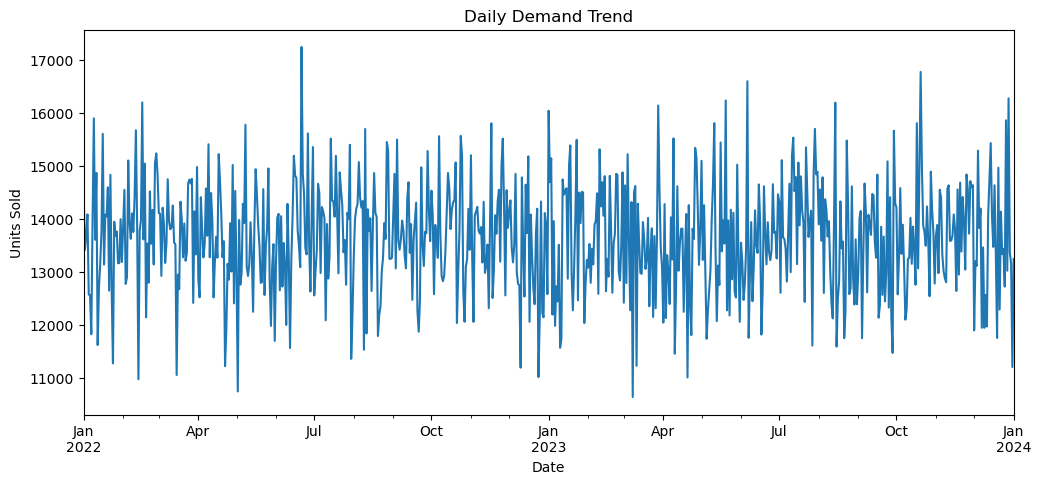

In [17]:
plt.figure(figsize=(12,5))
df.groupby('Date')['Units Sold'].sum().plot()
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


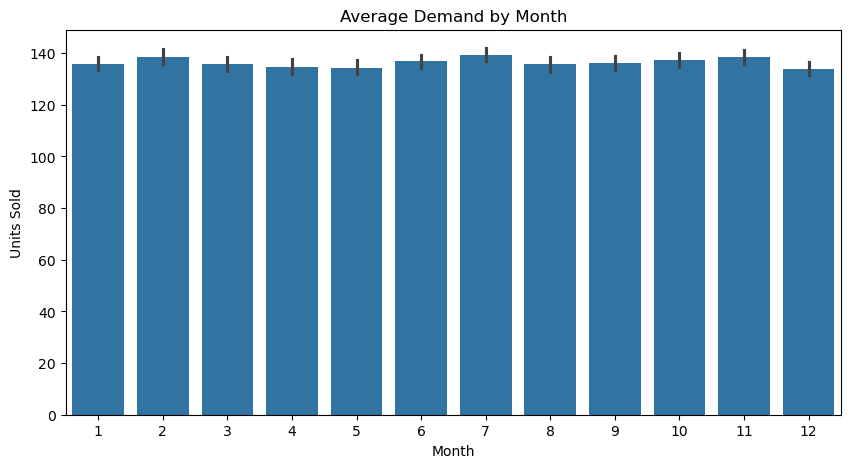

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x='month', y='Units Sold', data=df, estimator=np.mean)
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()


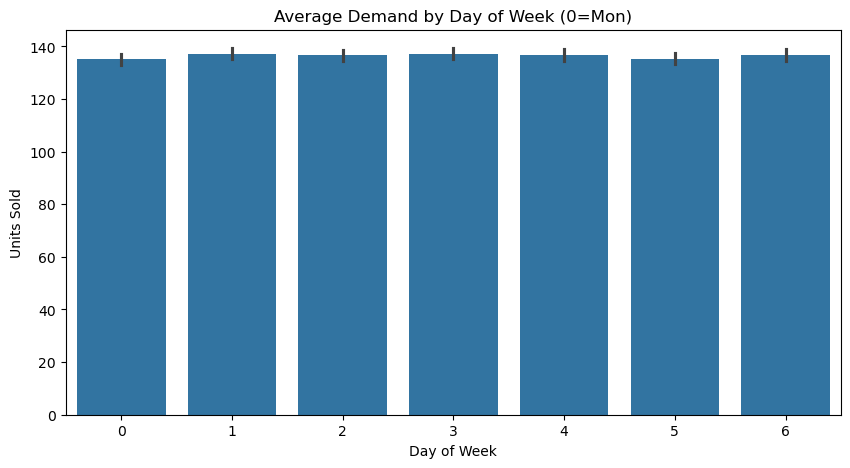

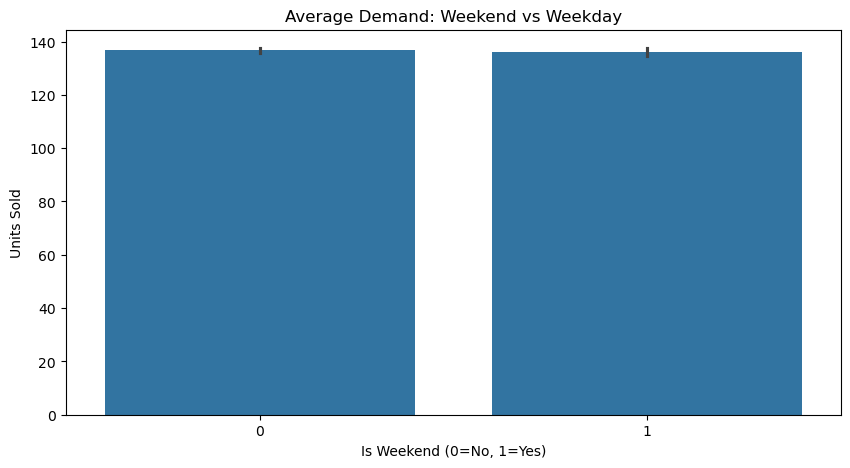

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='Units Sold', data=df, estimator=np.mean)
plt.title("Average Demand by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.show()
plt.figure(figsize=(10,5))
sns.barplot(x='is_weekend', y='Units Sold', data=df, estimator=np.mean)
plt.title("Average Demand: Weekend vs Weekday")
plt.xlabel("Is Weekend (0=No, 1=Yes)")
plt.ylabel("Units Sold")
plt.show()

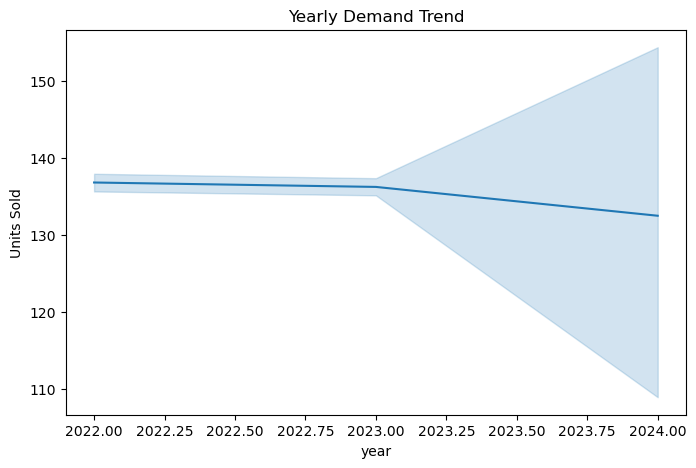

In [20]:
plt.figure(figsize=(8,5))
sns.lineplot(x='year', y='Units Sold', data=df, estimator=np.mean)
plt.title("Yearly Demand Trend")
plt.show()
                    


In [21]:
df['price_diff_competitor'] = df['Price'] - df['Competitor Pricing']
df['discount_flag'] = (df['Discount'] > 0).astype(int)
df.head()

,Date,Category,Region,Inventory Level,Units Sold,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,SKU_ID,year,month,day,day_of_week,week_of_year,is_weekend,price_diff_competitor,discount_flag
0,2022-01-01,Groceries,North,231,127,33.50,20,Rainy,0,29.69,Autumn,Groceries,2022,1,1,5,52,1,3.81,1
72,2022-01-01,Furniture,East,191,56,61.81,0,Sunny,0,63.92,Autumn,Furniture,2022,1,1,5,52,1,-2.11,0
71,2022-01-01,Electronics,North,349,9,14.25,5,Rainy,1,18.56,Spring,Electronics,2022,1,1,5,52,1,-4.31,1
70,2022-01-01,Electronics,West,205,46,54.84,0,Sunny,1,57.76,Spring,Electronics,2022,1,1,5,52,1,-2.92,0
69,2022-01-01,Groceries,East,447,104,33.48,15,Cloudy,0,37.15,Summer,Groceries,2022,1,1,5,52,1,-3.67,1


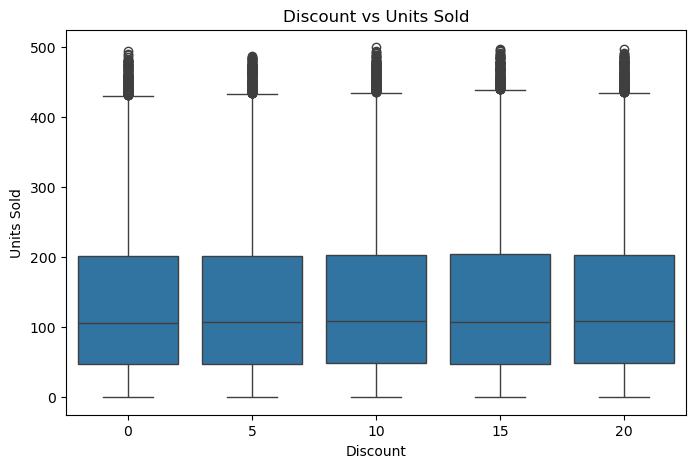

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Discount', y='Units Sold', data=df)
plt.title("Discount vs Units Sold")
plt.show()


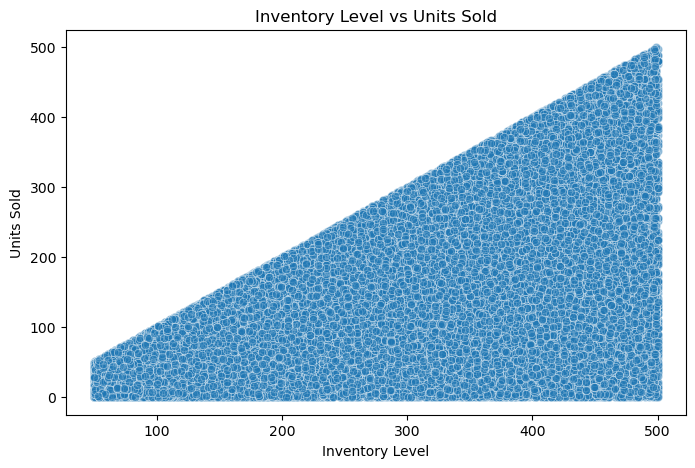

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Inventory Level', y='Units Sold', data=df, alpha=0.5)
plt.title("Inventory Level vs Units Sold")
plt.show()


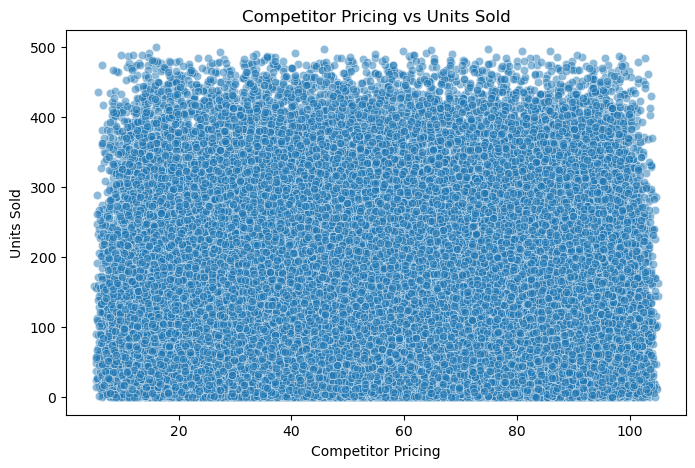

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Competitor Pricing',
    y='Units Sold',
    data=df,
    alpha=0.5
)
plt.title("Competitor Pricing vs Units Sold")
plt.show()


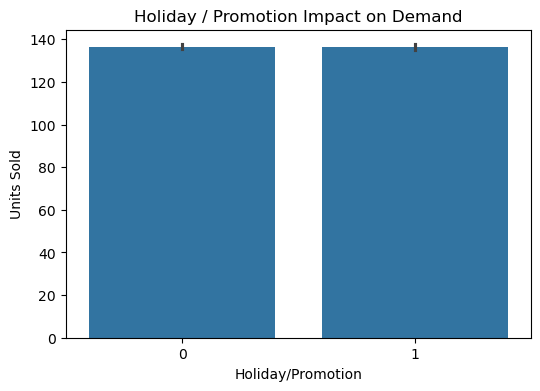

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='Holiday/Promotion', y='Units Sold', data=df)
plt.title("Holiday / Promotion Impact on Demand")
plt.show()


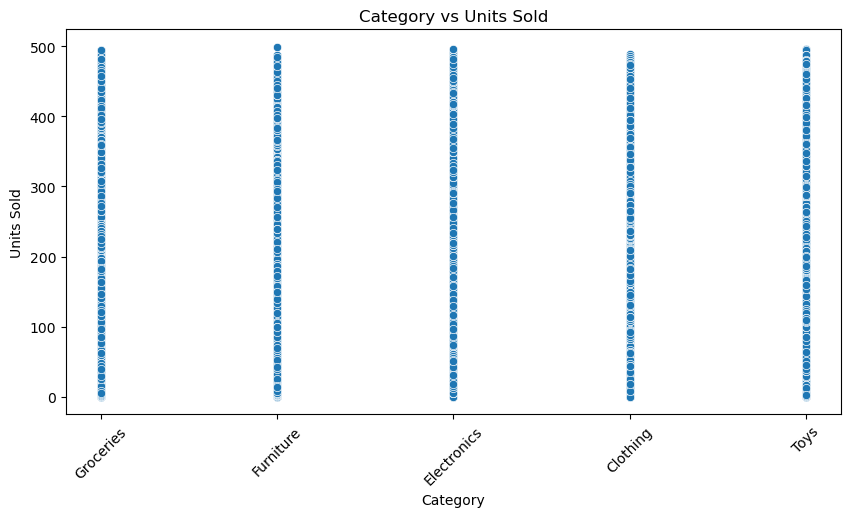

In [26]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Category', y='Units Sold', data=df)
plt.title("Category vs Units Sold")
plt.xticks(rotation=45)
plt.show()


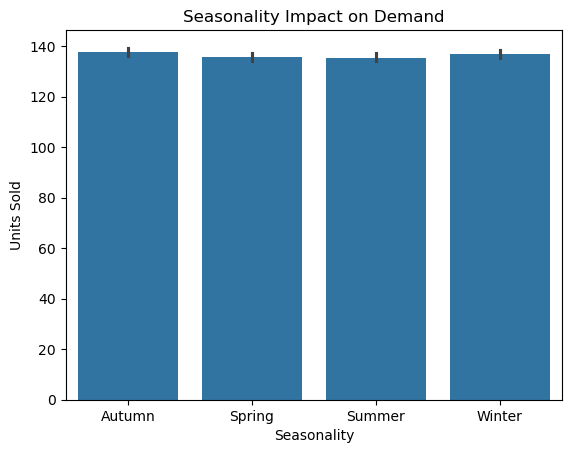

In [27]:
sns.barplot(x='Seasonality', y='Units Sold', data=df)
plt.title("Seasonality Impact on Demand")
plt.show()


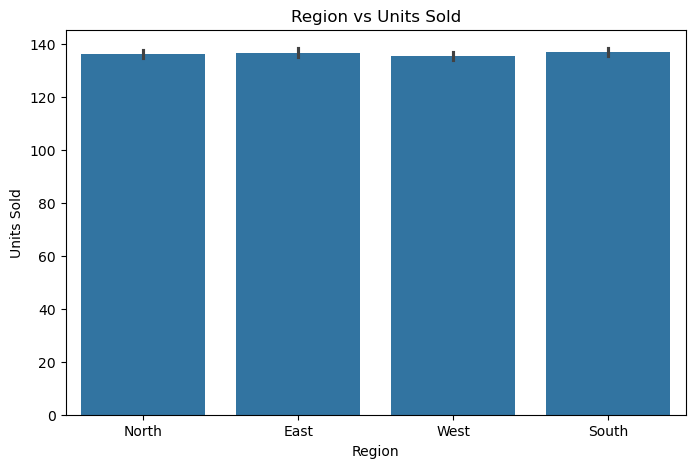

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Units Sold', data=df, estimator=np.mean)
plt.title("Region vs Units Sold")
plt.show()


In [29]:
df['lag_7'] = df.groupby('SKU_ID')['Units Sold'].shift(7)
df['lag_14'] = df.groupby('SKU_ID')['Units Sold'].shift(14)
df['rolling_7'] = df.groupby('SKU_ID')['Units Sold'].shift(1).rolling(7).mean()


In [30]:
df = df.sort_values(['SKU_ID', 'Date']).reset_index(drop=True)

df['lag_7']  = df.groupby('SKU_ID')['Units Sold'].shift(7)
df['lag_14'] = df.groupby('SKU_ID')['Units Sold'].shift(14)
df['lag_30'] = df.groupby('SKU_ID')['Units Sold'].shift(30)

df['rolling_7'] = (
    df.groupby('SKU_ID')['Units Sold']
      .shift(1)
      .rolling(7)
      .mean()
)

df['rolling_14'] = (
    df.groupby('SKU_ID')['Units Sold']
      .shift(1)
      .rolling(14)
      .mean()
)


In [31]:
df = df.dropna().reset_index(drop=True)


In [44]:
df.head

<bound method NDFrame.head of             Date  Category  Region  Inventory Level  Units Sold  Price  \
0     2022-01-02         0       0              257          93  70.69   
1     2022-01-02         0       1               76          54  69.21   
2     2022-01-02         0       1              171          39  11.44   
3     2022-01-02         0       0               92          74  58.89   
4     2022-01-02         0       2              488         464  70.99   
...          ...       ...     ...              ...         ...    ...   
72945 2024-01-01         4       2              433         167  67.54   
72946 2024-01-01         4       3              419         347  33.48   
72947 2024-01-01         4       3               53           2  63.66   
72948 2024-01-01         4       0              160         159  19.06   
72949 2024-01-01         4       1              258         110  41.30   

       Discount  Weather Condition  Holiday/Promotion  Competitor Pricing  \
0   

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['SKU_ID'] = le.fit_transform(df['SKU_ID'])
df['Weather Condition'] = le.fit_transform(df['Weather Condition'])
df['Seasonality'] = le.fit_transform(df['Seasonality'])


In [33]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Category', 'Region']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,Date,Category,Region,Inventory Level,Units Sold,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,...,day_of_week,week_of_year,is_weekend,price_diff_competitor,discount_flag,lag_7,lag_14,rolling_7,lag_30,rolling_14
0,2022-01-02,0,0,257,93,70.69,20,2,0,71.37,...,6,52,1,-0.68,1,69.0,24.0,123.571429,344.0,143.857143
1,2022-01-02,0,1,76,54,69.21,15,1,1,71.17,...,6,52,1,-1.96,1,89.0,312.0,127.000000,180.0,148.785714
2,2022-01-02,0,1,171,39,11.44,5,3,0,12.71,...,6,52,1,-1.27,1,178.0,12.0,122.000000,249.0,130.357143
3,2022-01-02,0,0,92,74,58.89,5,0,0,61.56,...,6,52,1,-2.67,1,183.0,325.0,102.142857,150.0,132.285714
4,2022-01-02,0,2,488,464,70.99,10,2,0,72.93,...,6,52,1,-1.94,1,203.0,283.0,86.571429,260.0,114.357143


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72950 entries, 0 to 72949
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   72950 non-null  datetime64[ns]
 1   Category               72950 non-null  int64         
 2   Region                 72950 non-null  int64         
 3   Inventory Level        72950 non-null  int64         
 4   Units Sold             72950 non-null  int64         
 5   Price                  72950 non-null  float64       
 6   Discount               72950 non-null  int64         
 7   Weather Condition      72950 non-null  int64         
 8   Holiday/Promotion      72950 non-null  int64         
 9   Competitor Pricing     72950 non-null  float64       
 10  Seasonality            72950 non-null  int64         
 11  SKU_ID                 72950 non-null  int64         
 12  year                   72950 non-null  int32         
 13  m

In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [36]:
TARGET = 'Units Sold'

FEATURES = [
    'Inventory Level','Price','Discount','Holiday/Promotion',
    'Competitor Pricing','year','month','day','day_of_week',
    'week_of_year','is_weekend','lag_7','lag_14','lag_30',
    'rolling_7','rolling_14','price_diff_competitor','discount_flag',
    'Category','Region','Weather Condition','Seasonality'
]


In [37]:
df.columns

Index(['Date', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Price',
       'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'SKU_ID', 'year', 'month', 'day',
       'day_of_week', 'week_of_year', 'is_weekend', 'price_diff_competitor',
       'discount_flag', 'lag_7', 'lag_14', 'rolling_7', 'lag_30',
       'rolling_14'],
      dtype='object')

In [38]:
split = df['Date'].quantile(0.8)

train = df[df['Date'] <= split]
test  = df[df['Date'] > split]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test   = test[FEATURES], test[TARGET]


In [39]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))


MAE: 69.19218599855489
RMSE: 88.648458560876


In [40]:
LEAD_TIME_DAYS = 7
SAFETY_STOCK_MULTIPLIER = 1.2


In [41]:
df['predicted_demand'] = model.predict(df[FEATURES])

df['avg_daily_demand'] = df['rolling_7'] / 7
df['safety_stock'] = df['avg_daily_demand'] * SAFETY_STOCK_MULTIPLIER

df['ROP'] = (df['avg_daily_demand'] * LEAD_TIME_DAYS) + df['safety_stock']

df['stock_status'] = np.where(
    df['Inventory Level'] < df['ROP'], 'UNDERSTOCK',
    np.where(df['Inventory Level'] > df['predicted_demand']*2, 'OVERSTOCK', 'OK')
)


In [42]:
final_view = df[[
    'Date','Category','Region','Inventory Level',
    'predicted_demand','ROP','stock_status'
]]

final_view.tail(10)


,Date,Category,Region,Inventory Level,predicted_demand,ROP,stock_status
72940,2024-01-01,4,0,69,34.725300,179.061224,UNDERSTOCK
72941,2024-01-01,4,0,223,125.023399,164.000000,OK
72942,2024-01-01,4,0,374,165.429031,156.469388,OVERSTOCK
72943,2024-01-01,4,3,133,70.109764,167.012245,UNDERSTOCK
72944,2024-01-01,4,0,236,124.102486,134.044898,OK
72945,2024-01-01,4,2,433,185.277481,135.885714,OVERSTOCK
72946,2024-01-01,4,3,419,193.711609,130.363265,OVERSTOCK
72947,2024-01-01,4,3,53,34.751053,157.306122,UNDERSTOCK
72948,2024-01-01,4,0,160,72.938522,146.930612,OVERSTOCK
72949,2024-01-01,4,1,258,150.656906,166.844898,OK


In [43]:
import os
import joblib

# Show where VS Code is running Jupyter from
print("📂 Jupyter working directory:")
print(os.getcwd())

# Define models directory relative to WORKING DIRECTORY
models_dir = os.path.join(os.getcwd(), "models")

# Create folder if it doesn't exist
os.makedirs(models_dir, exist_ok=True)

# Save model
model_path = os.path.join(models_dir, "model.pkl")
joblib.dump(model, model_path)

print("✅ Model saved successfully at:")
print(model_path)


📂 Jupyter working directory:
/Users/rushibankar/Downloads/Smart-Inventory-Project/notebooks
✅ Model saved successfully at:
/Users/rushibankar/Downloads/Smart-Inventory-Project/notebooks/models/model.pkl
